# StatcastDataset 欠損値分析

StatcastDataset で使用される全カラムについて欠損値の状況を分析する。

## 分析内容
1. 基本統計（データサイズ、全体の欠損率）
2. **各カラムの欠損値の割合**
3. **各Rowの欠損値数の分布**
4. 欠損値の年度別推移
5. 欠損値の共起パターン（どのカラムが同時に欠損するか）
6. ターゲット変数間の欠損連鎖

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

## 0. データ読み込み

In [2]:
DATA_DIR = Path("/workspace/datasets/statcast-customized/data")

# DataConfig で定義されたカラム一覧
CATEGORICAL_FEATURES = ["p_throws", "pitch_type", "batter", "stand", "base_out_state", "count_state"]
CONTINUOUS_FEATURES = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z", "plate_x", "plate_z"]
ORDINAL_FEATURES = ["inning_clipped", "is_inning_top", "diff_score_clipped", "pitch_number_clipped"]
TARGET_CLS = ["swing_attempt", "swing_result", "bb_type"]
TARGET_REG = ["launch_speed", "launch_angle", "hit_distance_sc"]

ALL_COLUMNS = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES + ORDINAL_FEATURES + TARGET_CLS + TARGET_REG

# 全 parquet ファイルを読み込み
files = sorted(glob.glob(str(DATA_DIR / "*.parquet")))
print(f"Parquet files found: {len(files)}")
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Total columns in dataset: {len(df.columns)}")
print(f"Columns used by StatcastDataset: {len(ALL_COLUMNS)}")

Parquet files found: 72
Total rows: 5,781,569
Total columns in dataset: 23
Columns used by StatcastDataset: 22


In [3]:
# 対象カラムのみ抽出（存在しないカラムがあれば報告）
missing_cols = [c for c in ALL_COLUMNS if c not in df.columns]
if missing_cols:
    print(f"WARNING: columns not found in data: {missing_cols}")
available_cols = [c for c in ALL_COLUMNS if c in df.columns]
df_sub = df[available_cols].copy()
print(f"Analyzing {len(available_cols)} columns")

Analyzing 22 columns


## 1. 基本統計

In [4]:
total_cells = df_sub.shape[0] * df_sub.shape[1]
total_missing = df_sub.isna().sum().sum()
print(f"総セル数:       {total_cells:,}")
print(f"欠損セル数:     {total_missing:,}")
print(f"全体の欠損率:   {total_missing / total_cells * 100:.2f}%")
print(f"欠損を含む行数: {df_sub.isna().any(axis=1).sum():,} / {len(df_sub):,} ({df_sub.isna().any(axis=1).mean() * 100:.2f}%)")

総セル数:       127,194,518
欠損セル数:     20,600,707
全体の欠損率:   16.20%
欠損を含む行数: 4,829,736 / 5,781,569 (83.54%)


## 2. 各カラムの欠損値の割合

In [5]:
# テーブル表示
col_missing = df_sub.isna().sum()
col_missing_pct = df_sub.isna().mean() * 100

def _feature_group(col: str) -> str:
    if col in CATEGORICAL_FEATURES:
        return "categorical"
    elif col in CONTINUOUS_FEATURES:
        return "continuous"
    elif col in ORDINAL_FEATURES:
        return "ordinal"
    elif col in TARGET_CLS:
        return "target_cls"
    elif col in TARGET_REG:
        return "target_reg"
    return "other"

summary = pd.DataFrame({
    "group": [_feature_group(c) for c in available_cols],
    "missing_count": col_missing,
    "missing_pct": col_missing_pct,
    "dtype": [str(df_sub[c].dtype) for c in available_cols],
}).sort_values("missing_pct", ascending=False)

display(summary.style.format({"missing_pct": "{:.2f}%", "missing_count": "{:,}"}).bar(subset=["missing_pct"], color="#ef5350"))

,group,missing_count,missing_pct,dtype
bb_type,target_cls,"4,765,438",82.42%,Int64
hit_distance_sc,target_reg,"4,032,299",69.74%,float64
launch_speed,target_reg,"4,004,282",69.26%,float64
launch_angle,target_reg,"4,003,018",69.24%,float64
swing_result,target_cls,"3,047,056",52.70%,Int64
release_spin_rate,continuous,"149,937",2.59%,float64
plate_x,continuous,"100,453",1.74%,float64
plate_z,continuous,"100,453",1.74%,float64
pitch_type,categorical,"99,598",1.72%,Int64
pfx_x,continuous,"99,518",1.72%,float64


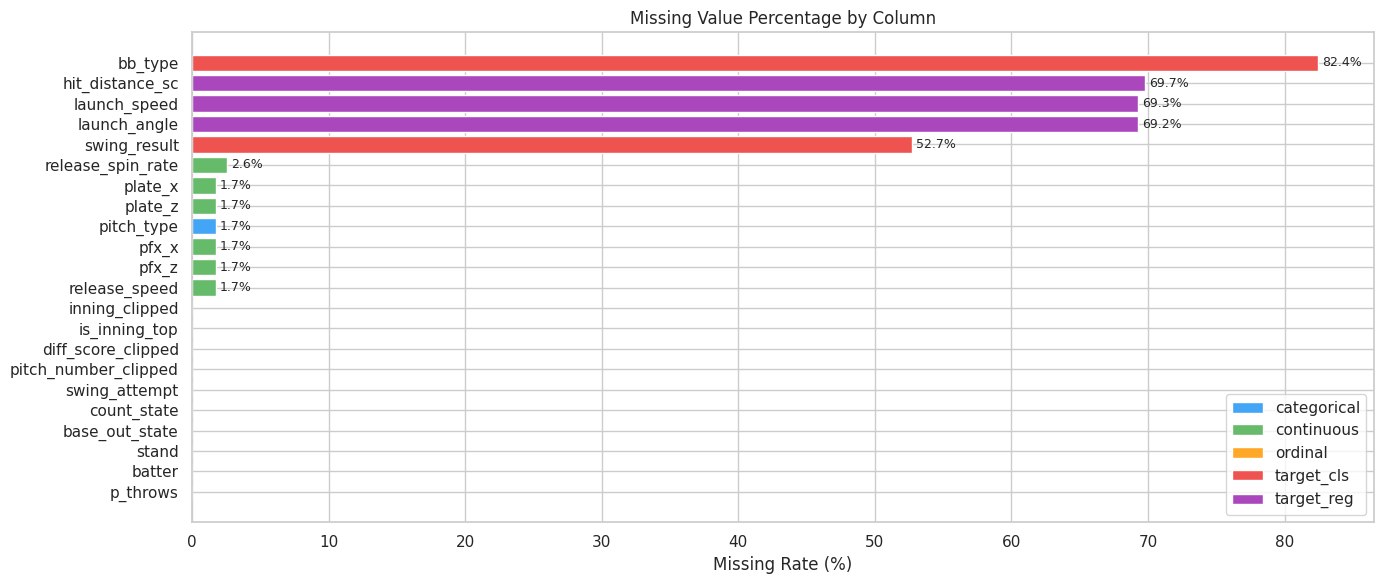

In [8]:
# 棒グラフ
fig, ax = plt.subplots(figsize=(14, 6))
colors = summary["group"].map({
    "categorical": "#42a5f5",
    "continuous": "#66bb6a",
    "ordinal": "#ffa726",
    "target_cls": "#ef5350",
    "target_reg": "#ab47bc",
}).fillna("gray")
ax.barh(summary.index, summary["missing_pct"], color=colors)
ax.set_xlabel("Missing Rate (%)")
ax.set_title("Missing Value Percentage by Column")
ax.invert_yaxis()
for i, pct in enumerate(summary["missing_pct"]):
    if pct > 0:
        ax.text(pct + 0.3, i, f"{pct:.1f}%", va="center", fontsize=9)

# 凡例
legend_elements = [
    Patch(facecolor="#42a5f5", label="categorical"),
    Patch(facecolor="#66bb6a", label="continuous"),
    Patch(facecolor="#ffa726", label="ordinal"),
    Patch(facecolor="#ef5350", label="target_cls"),
    Patch(facecolor="#ab47bc", label="target_reg"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## 3. 各Rowの欠損値数の分布

In [9]:
row_missing = df_sub.isna().sum(axis=1)

print("=== Row-level missing count 統計 ===")
print(row_missing.describe())
print()
print("=== 欠損数ごとの行数 ===")
vc = row_missing.value_counts().sort_index()
for n_miss, cnt in vc.items():
    print(f"  欠損 {n_miss:2d} 個: {cnt:>10,} 行 ({cnt / len(df_sub) * 100:6.2f}%)")

=== Row-level missing count 統計 ===
count    5.781569e+06
mean     3.563169e+00
std      2.277016e+00
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      1.200000e+01
dtype: float64

=== 欠損数ごとの行数 ===
  欠損  0 個:    951,833 行 ( 16.46%)
  欠損  1 個:    818,302 行 ( 14.15%)
  欠損  2 個:      8,034 行 (  0.14%)
  欠損  3 個:      4,162 行 (  0.07%)
  欠損  4 個:    896,178 行 ( 15.50%)
  欠損  5 個:  2,976,778 行 ( 51.49%)
  欠損  6 個:     26,016 行 (  0.45%)
  欠損  7 個:        236 行 (  0.00%)
  欠損  8 個:        705 行 (  0.01%)
  欠損  9 個:        190 行 (  0.00%)
  欠損 10 個:     23,791 行 (  0.41%)
  欠損 11 個:     21,887 行 (  0.38%)
  欠損 12 個:     53,457 行 (  0.92%)


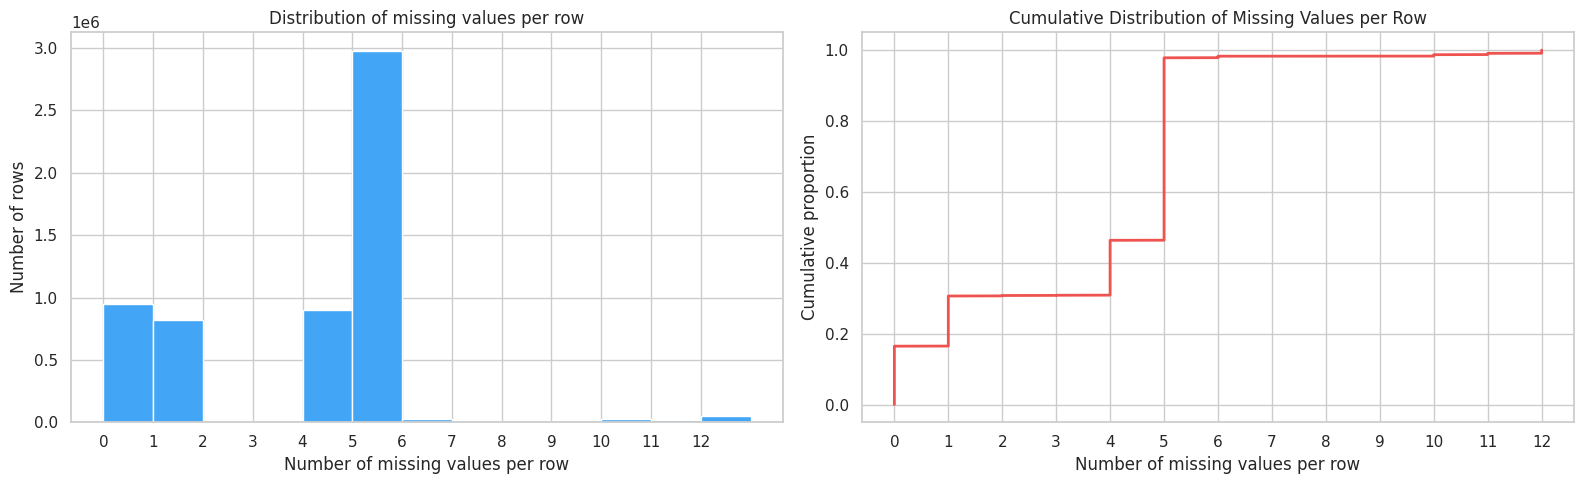

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ヒストグラム
axes[0].hist(row_missing, bins=range(0, row_missing.max() + 2), edgecolor="white", color="#42a5f5")
axes[0].set_xlabel("Number of missing values per row")
axes[0].set_ylabel("Number of rows")
axes[0].set_title("Distribution of missing values per row")
axes[0].set_xticks(range(0, row_missing.max() + 1))

# 累積分布
sorted_vals = np.sort(row_missing.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color="#ef5350", linewidth=2)
axes[1].set_xlabel("Number of missing values per row")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_title("Cumulative Distribution of Missing Values per Row")
axes[1].set_xticks(range(0, row_missing.max() + 1))

plt.tight_layout()
plt.show()

## 4. 特徴量グループ別の欠損率

In [12]:
groups = {
    "categorical": CATEGORICAL_FEATURES,
    "continuous": CONTINUOUS_FEATURES,
    "ordinal": ORDINAL_FEATURES,
    "target_cls": TARGET_CLS,
    "target_reg": TARGET_REG,
}
for name, cols in groups.items():
    cols_in_data = [c for c in cols if c in df_sub.columns]
    if not cols_in_data:
        continue
    sub = df_sub[cols_in_data]
    pct = sub.isna().mean().mean() * 100
    any_miss = sub.isna().any(axis=1).mean() * 100
    print(f"{name:15s}  avg missing rate: {pct:6.2f}%  rows w/ any missing: {any_miss:6.2f}%")

categorical      avg missing rate:   0.29%  rows w/ any missing:   1.72%
continuous       avg missing rate:   1.87%  rows w/ any missing:   2.61%
ordinal          avg missing rate:   0.00%  rows w/ any missing:   0.00%
target_cls       avg missing rate:  45.04%  rows w/ any missing:  82.42%
target_reg       avg missing rate:  69.41%  rows w/ any missing:  69.77%


## 5. 欠損値の年度別推移

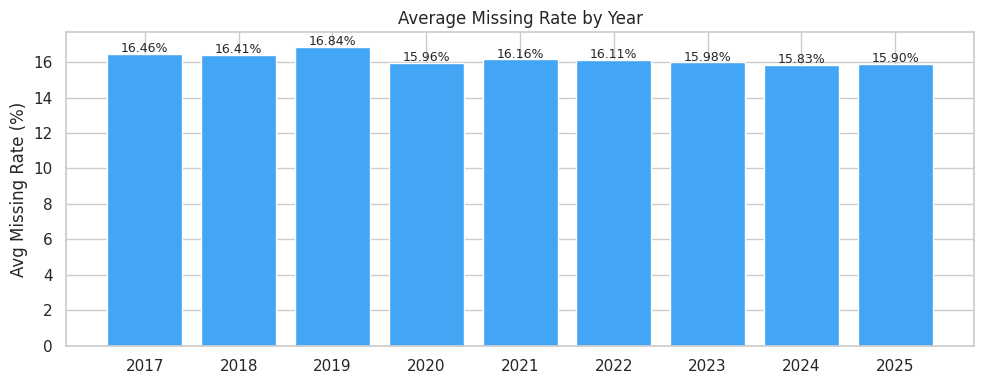

In [14]:
# parquet ファイル名から年月を抽出して集計
records = []
for f in files:
    fname = Path(f).stem  # e.g. statcast_2017_04
    parts = fname.split("_")
    year = int(parts[1])
    month = int(parts[2])
    chunk = pd.read_parquet(f)
    chunk_sub = chunk[[c for c in available_cols if c in chunk.columns]]
    records.append({
        "year": year,
        "month": month,
        "n_rows": len(chunk_sub),
        "missing_rate": chunk_sub.isna().mean().mean() * 100,
    })

ts = pd.DataFrame(records)
yearly = ts.groupby("year").apply(lambda g: np.average(g["missing_rate"], weights=g["n_rows"]), include_groups=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index.astype(str), yearly.values, color="#42a5f5")
ax.set_ylabel("Avg Missing Rate (%)")
ax.set_title("Average Missing Rate by Year")
for i, v in enumerate(yearly.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. 欠損値の共起パターン（ヒートマップ）

欠損が発生するカラム同士がどの程度共起するか確認する。

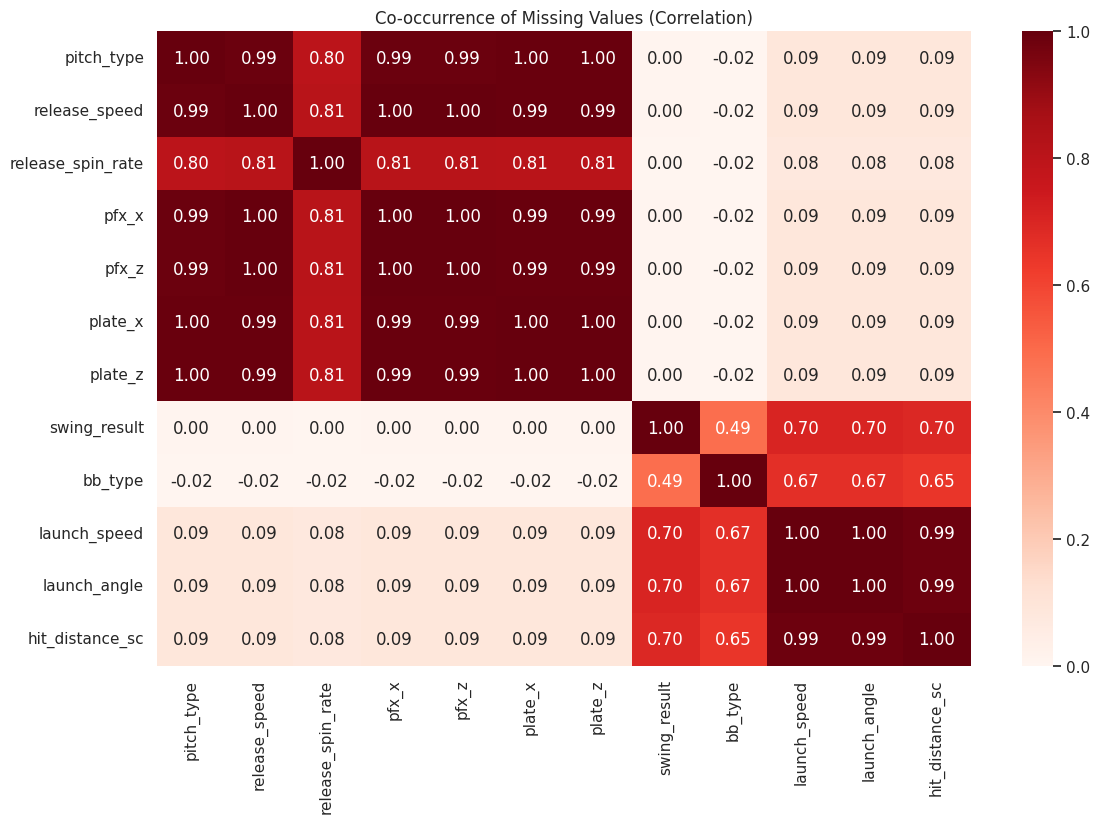

In [16]:
# 欠損のあるカラムだけ抽出
cols_with_missing = [c for c in available_cols if df_sub[c].isna().any()]
if len(cols_with_missing) >= 2:
    missing_indicator = df_sub[cols_with_missing].isna().astype(int)
    corr = missing_indicator.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_missing)), max(6, len(cols_with_missing) * 0.7)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=ax)
    ax.set_title("Co-occurrence of Missing Values (Correlation)")
    plt.tight_layout()
    plt.show()
else:
    print("欠損のあるカラムが2つ未満のため、共起分析をスキップ")

## 7. ターゲット変数の欠損連鎖

`swing_attempt=0`（スイングなし）の場合、`swing_result` / `bb_type` / 回帰ターゲット は欠損になるはず。  
この論理的な欠損パターンを確認する。

In [17]:
target_cols = [c for c in TARGET_CLS + TARGET_REG if c in df_sub.columns]

if "swing_attempt" in df_sub.columns:
    for sa_val in [0, 1]:
        mask = df_sub["swing_attempt"] == sa_val
        subset = df_sub.loc[mask, target_cols]
        print(f"\n--- swing_attempt = {sa_val} ({mask.sum():,} rows) ---")
        miss = subset.isna().mean() * 100
        for col, pct in miss.items():
            print(f"  {col:20s}: {pct:6.2f}% missing")

    # swing_result ごとの bb_type / reg targets 欠損
    if "swing_result" in df_sub.columns:
        print("\n--- swing_result 値別の bb_type / 回帰ターゲット欠損率 ---")
        check_cols = [c for c in ["bb_type"] + TARGET_REG if c in df_sub.columns]
        grouped = df_sub.groupby("swing_result")[check_cols].apply(lambda g: g.isna().mean() * 100)
        display(grouped.style.format("{:.1f}%"))


--- swing_attempt = 0 (3,047,056 rows) ---
  swing_attempt       :   0.00% missing
  swing_result        : 100.00% missing
  bb_type             : 100.00% missing
  launch_speed        : 100.00% missing
  launch_angle        : 100.00% missing
  hit_distance_sc     : 100.00% missing

--- swing_attempt = 1 (2,734,513 rows) ---
  swing_attempt       :   0.00% missing
  swing_result        :   0.00% missing
  bb_type             :  62.84% missing
  launch_speed        :  35.01% missing
  launch_angle        :  34.96% missing
  hit_distance_sc     :  36.03% missing

--- swing_result 値別の bb_type / 回帰ターゲット欠損率 ---


,bb_type,launch_speed,launch_angle,hit_distance_sc
swing_result,,,,
0,100.0%,22.5%,22.4%,22.5%
1,0.0%,2.8%,2.7%,5.5%
2,100.0%,100.0%,100.0%,100.0%
3,100.0%,100.0%,100.0%,100.0%
4,100.0%,100.0%,100.0%,100.0%
5,100.0%,100.0%,100.0%,100.0%
6,100.0%,100.0%,100.0%,100.0%
7,100.0%,100.0%,100.0%,100.0%
8,100.0%,0.0%,0.0%,0.0%


## 8. 連続値特徴量の欠損と非欠損の基本統計比較

欠損が存在する連続値カラムについて、他のカラムの統計が欠損・非欠損で異なるか確認する。

In [18]:
cont_with_missing = [c for c in CONTINUOUS_FEATURES if c in df_sub.columns and df_sub[c].isna().any()]

for col in cont_with_missing:
    mask = df_sub[col].isna()
    other_cont = [c for c in CONTINUOUS_FEATURES if c in df_sub.columns and c != col]
    if not other_cont:
        continue
    print(f"\n=== {col} が欠損する行 vs 非欠損の行 ===")
    comp = pd.DataFrame({
        f"{c}_present_mean": [df_sub.loc[~mask, c].mean()]
        for c in other_cont
    } | {
        f"{c}_missing_mean": [df_sub.loc[mask, c].mean()]
        for c in other_cont
    })
    display(comp.T.rename(columns={0: "mean"}))

if not cont_with_missing:
    print("連続値特徴量に欠損がないため、スキップ")


=== release_speed が欠損する行 vs 非欠損の行 ===


,mean
release_spin_rate_present_mean,2247.093198
pfx_x_present_mean,-0.137311
pfx_z_present_mean,0.637287
plate_x_present_mean,0.041781
plate_z_present_mean,2.274699
release_spin_rate_missing_mean,2380.023256
pfx_x_missing_mean,0.750000
pfx_z_missing_mean,1.060000
plate_x_missing_mean,0.057946
plate_z_missing_mean,2.136148



=== release_spin_rate が欠損する行 vs 非欠損の行 ===


,mean
release_speed_present_mean,88.931730
pfx_x_present_mean,-0.139872
pfx_z_present_mean,0.640811
plate_x_present_mean,0.040533
plate_z_present_mean,2.277242
release_speed_missing_mean,84.909816
pfx_x_missing_mean,0.147500
pfx_z_missing_mean,0.245402
plate_x_missing_mean,0.181381
plate_z_missing_mean,1.990281



=== pfx_x が欠損する行 vs 非欠損の行 ===


...

,mean
release_speed_present_mean,88.896117
release_spin_rate_present_mean,2247.096058
pfx_x_present_mean,-0.137310
plate_x_present_mean,0.041778
plate_z_present_mean,2.274709
release_speed_missing_mean,75.988710
release_spin_rate_missing_mean,2136.574468
pfx_x_missing_mean,NaN
plate_x_missing_mean,0.265361
plate_z_missing_mean,1.588711



=== plate_x が欠損する行 vs 非欠損の行 ===


,mean
release_speed_present_mean,88.896169
release_spin_rate_present_mean,2247.103067
pfx_x_present_mean,-0.137310
pfx_z_present_mean,0.637300
plate_z_present_mean,2.274698
release_speed_missing_mean,87.354265
release_spin_rate_missing_mean,2190.829571
pfx_x_missing_mean,-0.137922
pfx_z_missing_mean,0.569172
plate_z_missing_mean,NaN



=== plate_z が欠損する行 vs 非欠損の行 ===


,mean
release_speed_present_mean,88.896169
release_spin_rate_present_mean,2247.103067
pfx_x_present_mean,-0.137310
pfx_z_present_mean,0.637300
plate_x_present_mean,0.041781
release_speed_missing_mean,87.354265
release_spin_rate_missing_mean,2190.829571
pfx_x_missing_mean,-0.137922
pfx_z_missing_mean,0.569172
plate_x_missing_mean,NaN


## 9. まとめ

In [19]:
print("=" * 60)
print("欠損値分析 サマリー")
print("=" * 60)
print(f"総行数: {len(df_sub):,}")
print(f"分析カラム数: {len(available_cols)}")
print(f"全体欠損率: {df_sub.isna().mean().mean() * 100:.2f}%")
print()
print("欠損率が高いカラム（> 1%）:")
high_miss = summary[summary["missing_pct"] > 1].sort_values("missing_pct", ascending=False)
for col, row in high_miss.iterrows():
    print(f"  {col:25s} {row['missing_pct']:6.2f}%  ({row['group']})")
print()
print("完全に欠損のないカラム:")
no_miss = summary[summary["missing_pct"] == 0]
for col in no_miss.index:
    print(f"  {col}")
print()
print(f"欠損が1つもない行の割合: {(row_missing == 0).mean() * 100:.2f}%")
print(f"行あたりの平均欠損数: {row_missing.mean():.2f}")

欠損値分析 サマリー
総行数: 5,781,569
分析カラム数: 22
全体欠損率: 16.20%

欠損率が高いカラム（> 1%）:
  bb_type                    82.42%  (target_cls)
  hit_distance_sc            69.74%  (target_reg)
  launch_speed               69.26%  (target_reg)
  launch_angle               69.24%  (target_reg)
  swing_result               52.70%  (target_cls)
  release_spin_rate           2.59%  (continuous)
  plate_x                     1.74%  (continuous)
  plate_z                     1.74%  (continuous)
  pitch_type                  1.72%  (categorical)
  pfx_x                       1.72%  (continuous)
  pfx_z                       1.72%  (continuous)
  release_speed               1.72%  (continuous)

完全に欠損のないカラム:
  inning_clipped
  is_inning_top
  diff_score_clipped
  pitch_number_clipped
  swing_attempt
  count_state
  base_out_state
  stand
  batter
  p_throws

欠損が1つもない行の割合: 16.46%
行あたりの平均欠損数: 3.56
